# Importing labraries

In [40]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# import the Datasets

In [41]:
df = pd.read_csv('dataset/Breast Cancer Wisconsin.csv').drop(columns=['Unnamed: 32', 'id'])

# Explore the Datasets

In [42]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
df.tail()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [45]:
# Vérifier les dimensions
df.shape

(569, 31)

In [46]:
# Noms des colonnes 
df.columns.tolist()

['diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [47]:
# Type de chaque colonne
df.dtypes

diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [48]:
# Statistiques descriptives

# Exclure la colonne 'diagnosis'
df_features = df.drop(columns=['diagnosis'])

# Résumé statistique
df_features.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


diagnosis
B    357
M    212
Name: count, dtype: int64


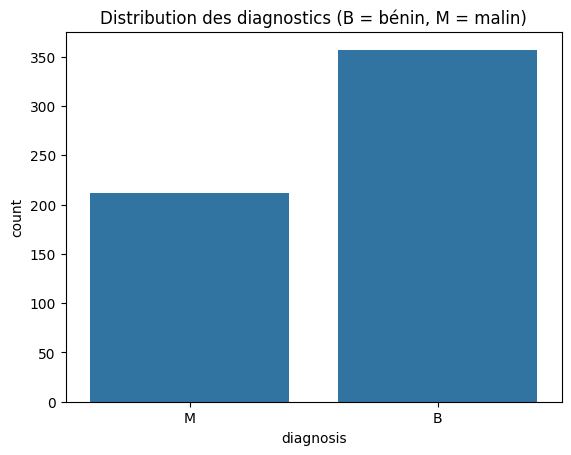

In [49]:
# Explorer la cible (diagnosis)

print(df['diagnosis'].value_counts())

sns.countplot(data=df, x='diagnosis')
plt.title("Distribution des diagnostics (B = bénin, M = malin)")
plt.show()


# Visualize the relationships between features

In [50]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

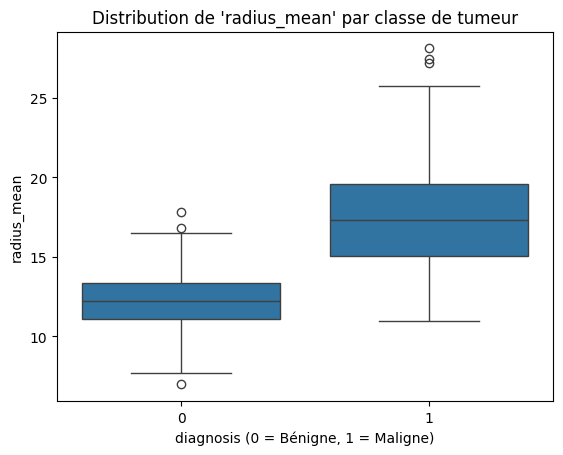

In [51]:
#  Boxplot : voir la distribution d’une caractéristique par classe

sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Distribution de 'radius_mean' par classe de tumeur")
plt.xlabel("diagnosis (0 = Bénigne, 1 = Maligne)")
plt.ylabel("radius_mean")
plt.show()

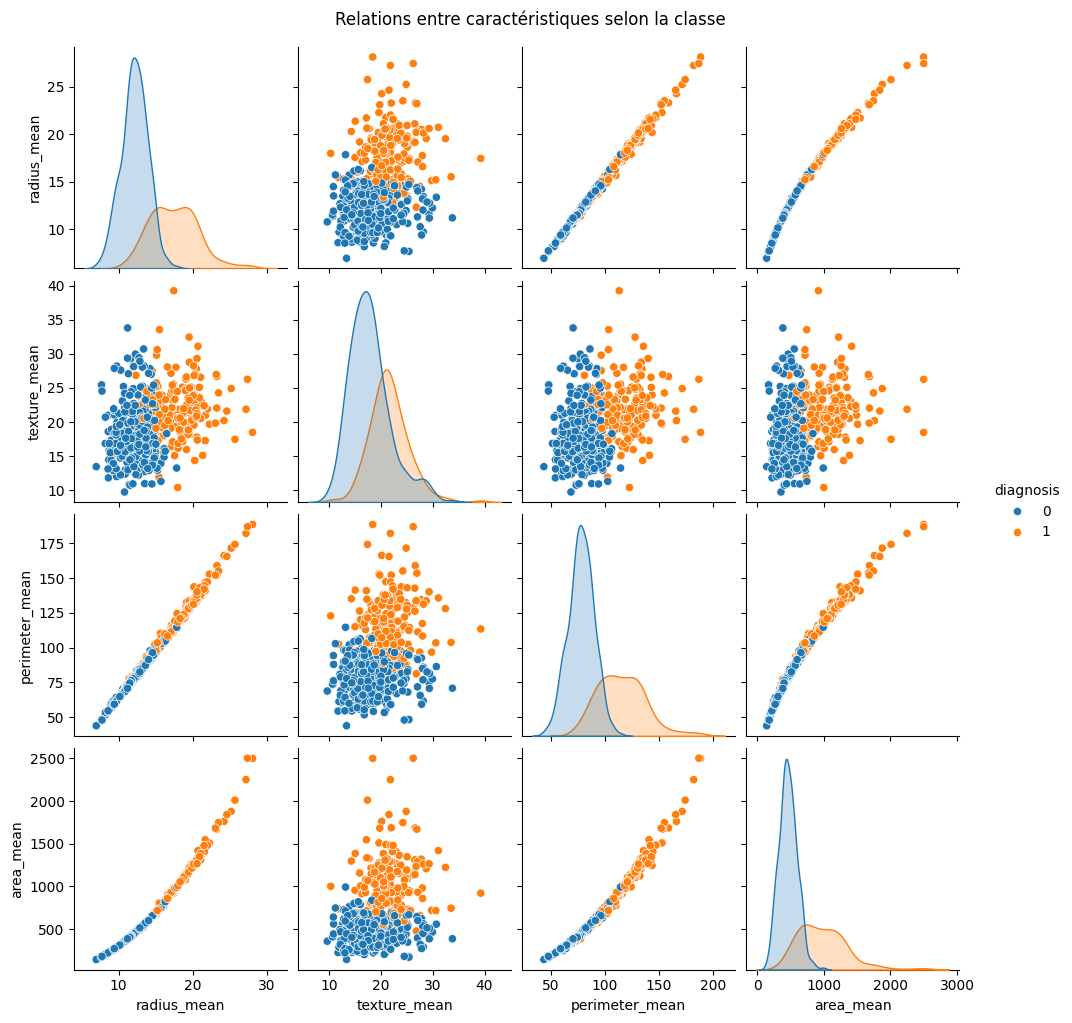

In [52]:
# Pairplot : visualiser plusieurs relations à la fois

# Choisir quelques colonnes importantes
colonnes = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']

# Pairplot
sns.pairplot(df[colonnes], hue='diagnosis', diag_kind='kde')
plt.suptitle("Relations entre caractéristiques selon la classe", y=1.02)
plt.show()

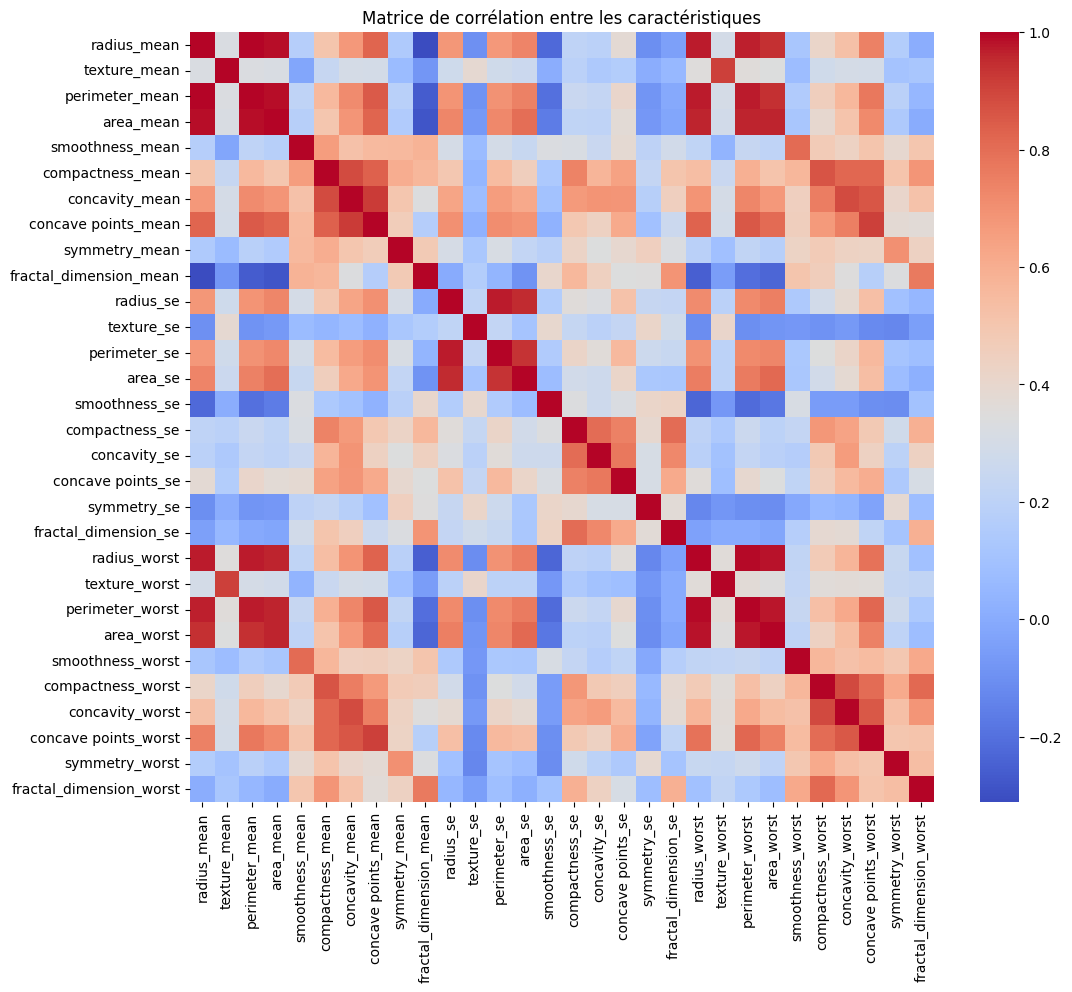

In [53]:
# Matrice de corrélation

plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns='diagnosis').corr(), cmap='coolwarm', annot=False)
plt.title("Matrice de corrélation entre les caractéristiques")
plt.show()

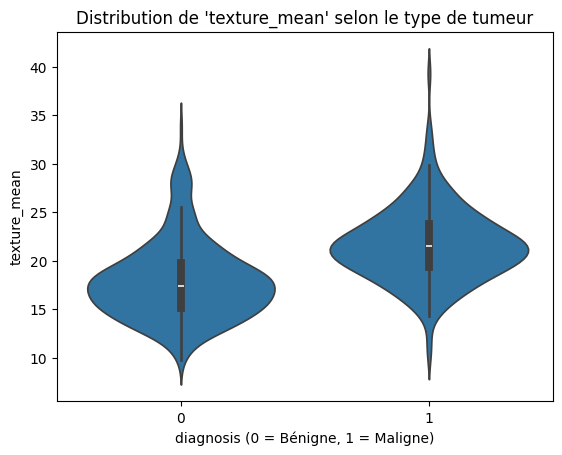

In [54]:
# Violinplot 

sns.violinplot(x='diagnosis', y='texture_mean', data=df)
plt.title("Distribution de 'texture_mean' selon le type de tumeur")
plt.xlabel("diagnosis (0 = Bénigne, 1 = Maligne)")
plt.ylabel("texture_mean")
plt.show()

# réduction de dimension (PCA)

In [55]:
# Corrélation de chaque variable avec la cible (diagnosis)
correlations = df.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)

print("Variables les plus corrélées avec le diagnostic :")
print(correlations)

Variables les plus corrélées avec le diagnostic :
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se 

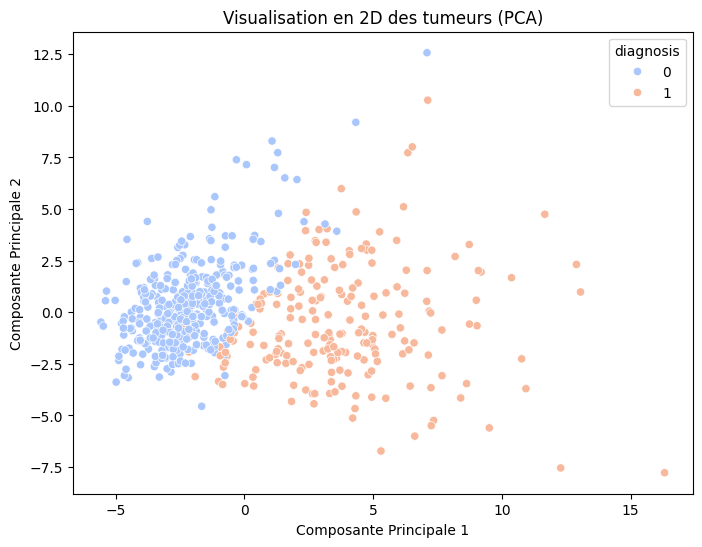

In [56]:
# Séparer les features et la cible
x = df.drop(columns='diagnosis')
y = df['diagnosis']

# Normaliser les données (important pour la PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Appliquer la PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Mettre sous forme de DataFrame
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['diagnosis'] = y

# Visualisation
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='diagnosis', data=df_pca, palette='coolwarm')
plt.title("Visualisation en 2D des tumeurs (PCA)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.show()

# Preprocess the datasets

## null Values

In [57]:
# Vérifier les valeurs manquantes
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

## Normalization of features

In [58]:
# Séparer les variables explicatives (X) et la cible (y)
x = df.drop(columns='diagnosis')

y = df['diagnosis']

# Créer le normaliseur
scaler = StandardScaler()

# Appliquer la normalisation
X_scaled = scaler.fit_transform(x)

# (Optionnel) Convertir en DataFrame pour voir le résultat
import pandas as pd
X_scaled_df = pd.DataFrame(X_scaled, columns=x.columns)

# Aperçu
X_scaled_df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## train test samples

In [59]:
# Division 80% train / 20% test (par défaut shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  # données (features) normalisées
    y,         # cible
    test_size=0.2,  # 20% pour test
    random_state=88 # pour reproductibilité
)

In [60]:
# Afficher les dimensions pour vérifier
print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test  :", y_test.shape)

Taille X_train : (455, 30)
Taille X_test  : (114, 30)
Taille y_train : (455,)
Taille y_test  : (114,)


# Apply a ML model

## regression logistique

In [61]:
# Créer le modèle
model = LogisticRegression(max_iter=1000)

# Entraîner sur les données d'entraînement
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [62]:
y_train

396    0
286    0
407    0
399    0
310    0
      ..
197    1
112    0
362    0
433    1
288    0
Name: diagnosis, Length: 455, dtype: int64

In [63]:
# Prédictions
y_pred = model.predict(X_test)

# Nombre de bonnes prédictions
correct = (y_test == y_pred).sum()
print(f"Nombre de prédictions correctes : {correct}")

# Ou bien, la précision en pourcentage :
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision : {accuracy:.2f}")

Nombre de prédictions correctes : 114
Précision : 1.00


In [64]:
# Optimisation des hyperparamètres d'une Régression Logistique

# Définir une grille de valeurs à tester
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],            # Inverse de la régularisation
    'penalty': ['l1', 'l2'],                 # Type de pénalité (l1 = Lasso, l2 = Ridge)
    'solver': ['liblinear']                 # 'liblinear' supporte l1 et l2
}

# Créer le modèle de base
logreg = LogisticRegression(max_iter=1000)

# Créer la recherche par grille
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Exécuter la recherche sur l'ensemble d'entraînement
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs hyperparamètres :", grid_search.best_params_)


Meilleurs hyperparamètres : {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [65]:
# Meilleur modèle trouvé par GridSearch
best_model = grid_search.best_estimator_

# Prédictions
y_pred_best = best_model.predict(X_test)

# Nombre de bonnes prédictions
correct = (y_test == y_pred_best).sum()
print(f"Nombre de prédictions correctes : {correct}")

# Ou bien, la précision en pourcentage :
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Précision : {accuracy:.2f}")

Nombre de prédictions correctes : 114
Précision : 1.00


## k-nearest neighbors (KNN)

In [66]:
# Créer le modèle KNN avec k=5 (par défaut)
knn = KNeighborsClassifier(n_neighbors=5)

# Entraîner le modèle sur l'ensemble d'entraînement
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [67]:
# Prédictions sur les données de test
y_pred_knn = knn.predict(X_test)

# Nombre de bonnes prédictions
correct = (y_test == y_pred_knn).sum()
print(f"Nombre de prédictions correctes : {correct}")

# Ou bien, la précision en pourcentage :
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Précision : {accuracy:.2f}")

Nombre de prédictions correctes : 112
Précision : 0.98


In [68]:
# Définir la grille des valeurs à tester pour k
param_grid = {
    'n_neighbors': list(range(1, 21)),  # k = 1 à 20
    'weights': ['uniform', 'distance'],  # pondération des voisins
    'metric': ['euclidean', 'manhattan']  # distance utilisée
}

# Créer le modèle KNN
knn = KNeighborsClassifier()

# Recherche par validation croisée (5 plis)
grid_search_knn = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Exécuter la recherche sur l'ensemble d'entraînement
grid_search_knn.fit(X_train, y_train)

# Meilleurs paramètres trouvés
print("Meilleurs hyperparamètres KNN :", grid_search_knn.best_params_)

Meilleurs hyperparamètres KNN : {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}


In [69]:
# Meilleur modèle KNN
best_knn = grid_search_knn.best_estimator_

# Prédiction sur le test set
y_pred_best_knn = best_knn.predict(X_test)

# Nombre de bonnes prédictions
correct = (y_test == y_pred_best_knn).sum()
print(f"Nombre de prédictions correctes : {correct}")

# Ou bien, la précision en pourcentage :
accuracy = accuracy_score(y_test, y_pred_best_knn)
print(f"Précision : {accuracy:.2f}")

Nombre de prédictions correctes : 112
Précision : 0.98


## Decision Tree

In [70]:
# Créer le modèle avec une profondeur max (optionnel)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Entraîner sur les données d'entraînement
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [71]:
# Prédictions sur les données de test
y_pred_dt = dt.predict(X_test)

# Nombre de bonnes prédictions
correct = (y_test == y_pred_dt).sum()
print(f"Nombre de prédictions correctes : {correct}")

# Ou bien, la précision en pourcentage :
accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Précision : {accuracy:.2f}")

Nombre de prédictions correctes : 106
Précision : 0.93


In [72]:
# Définir la grille des hyperparamètres à tester
param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Modèle de base
dt = DecisionTreeClassifier(random_state=42)

# GridSearch avec validation croisée 5-folds
grid_search_dt = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Lancer la recherche sur les données d'entraînement
grid_search_dt.fit(X_train, y_train)

# Meilleurs hyperparamètres trouvés
print("Meilleurs hyperparamètres Arbre de décision :", grid_search_dt.best_params_)

Meilleurs hyperparamètres Arbre de décision : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [73]:
best_dt = grid_search_dt.best_estimator_

# Prédiction sur l’ensemble de test
y_pred_best_dt = best_dt.predict(X_test)

# Nombre de bonnes prédictions
correct = (y_test == y_pred_best_dt).sum()
print(f"Nombre de prédictions correctes : {correct}")

# Ou bien, la précision en pourcentage :
accuracy = accuracy_score(y_test, y_pred_best_dt)
print(f"Précision : {accuracy:.2f}")

Nombre de prédictions correctes : 103
Précision : 0.90


## Model Evaluation


=== Évaluation du modèle : Régression Logistique ===
Accuracy : 1.0000
Precision : 1.0000
Recall : 1.0000
F1 Score : 1.0000

Rapport de classification :
              precision    recall  f1-score   support

     Bénigne       1.00      1.00      1.00        75
     Maligne       1.00      1.00      1.00        39

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



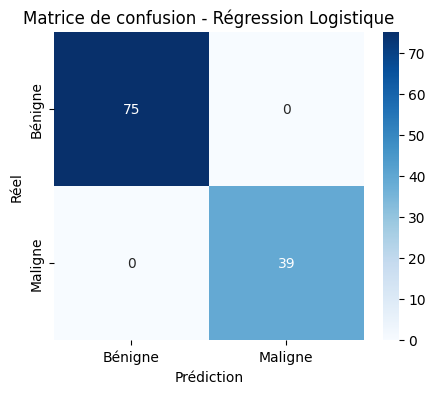


=== Évaluation du modèle : KNN ===
Accuracy : 0.9825
Precision : 1.0000
Recall : 0.9487
F1 Score : 0.9737

Rapport de classification :
              precision    recall  f1-score   support

     Bénigne       0.97      1.00      0.99        75
     Maligne       1.00      0.95      0.97        39

    accuracy                           0.98       114
   macro avg       0.99      0.97      0.98       114
weighted avg       0.98      0.98      0.98       114



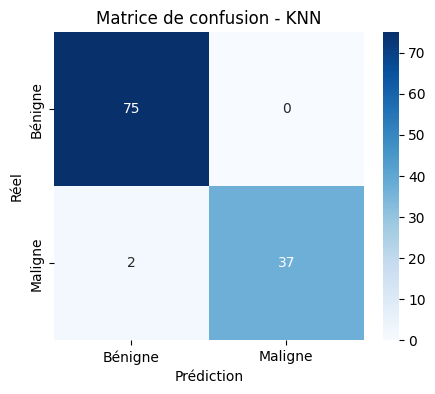


=== Évaluation du modèle : Arbre de décision ===
Accuracy : 0.9035
Precision : 0.8333
Recall : 0.8974
F1 Score : 0.8642

Rapport de classification :
              precision    recall  f1-score   support

     Bénigne       0.94      0.91      0.93        75
     Maligne       0.83      0.90      0.86        39

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.89       114
weighted avg       0.91      0.90      0.90       114



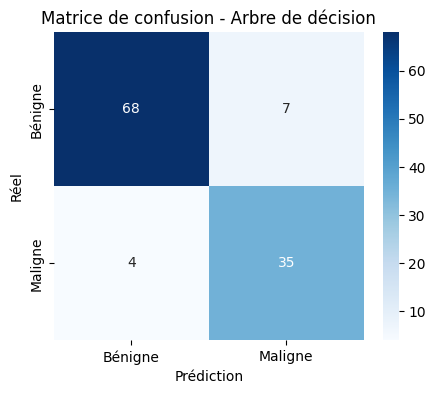

In [74]:
# Dictionnaire des modèles optimisés et leurs noms
modeles = {
    "Régression Logistique": best_model,     # issu de GridSearchCV sur LogisticRegression
    "KNN": best_knn,                         # issu de GridSearchCV sur KNeighborsClassifier
    "Arbre de décision": best_dt             # issu de GridSearchCV sur DecisionTreeClassifier
}

# Stockage des métriques pour comparaison
resultats = []

for nom, modele in modeles.items():
    print(f"\n=== Évaluation du modèle : {nom} ===")
    
    # Prédictions
    y_pred = modele.predict(X_test)
    
    # Calcul métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Afficher les métriques
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, target_names=["Bénigne", "Maligne"]))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Bénigne", "Maligne"],
                yticklabels=["Bénigne", "Maligne"])
    plt.title(f"Matrice de confusion - {nom}")
    plt.xlabel("Prédiction")
    plt.ylabel("Réel")
    plt.show()
    
    # Stocker les résultats dans une liste
    resultats.append({
        "Modèle": nom,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [75]:
# Créer un DataFrame pandas avec les résultats
df_resultats = pd.DataFrame(resultats)

# Afficher le tableau trié par F1 Score décroissant
print("\n=== Comparaison des modèles ===")
display(df_resultats.sort_values(by="F1 Score", ascending=False))


=== Comparaison des modèles ===


,Modèle,Accuracy,Precision,Recall,F1 Score
0,Régression Logistique,1.000000,1.000000,1.000000,1.000000
1,KNN,0.982456,1.000000,0.948718,0.973684
2,Arbre de décision,0.903509,0.833333,0.897436,0.864198


# Model Interpretation

## Régression Logistique

- **Coefficients des variables : La régression logistique est un modèle linéaire, donc chaque caractéristique a un coefficient qui mesure son influence sur la prédiction (positive ou négative).**

- **Un coefficient élevé (en valeur absolue) signifie que la variable a une forte influence sur la classification.**

In [76]:
coef = best_model.coef_[0]  # tableau des coefficients pour chaque feature
features = x.columns

# Associer coefficients et noms de features
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coef})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()

# Trier par importance
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print("Top 10 des caractéristiques influentes (régression logistique) :")
print(coef_df.head(10))

Top 10 des caractéristiques influentes (régression logistique) :
                 Feature  Coefficient  AbsCoefficient
20          radius_worst     2.692299        2.692299
10             radius_se     2.529887        2.529887
23            area_worst     1.705397        1.705397
21         texture_worst     1.462520        1.462520
27  concave points_worst     1.100787        1.100787
26       concavity_worst     0.950608        0.950608
15        compactness_se    -0.801810        0.801810
24      smoothness_worst     0.634127        0.634127
7    concave points_mean     0.578518        0.578518
28        symmetry_worst     0.545720        0.545720


## Decision Tree

**Arbre de décision : on peut extraire l'importance des variables via feature_importances_.**

Top 10 des caractéristiques importantes (arbre de décision) :
                 Feature  Importance
23            area_worst    0.808292
27  concave points_worst    0.128307
11            texture_se    0.031773
24      smoothness_worst    0.021423
26       concavity_worst    0.008213
12          perimeter_se    0.001993
5       compactness_mean    0.000000
4        smoothness_mean    0.000000
6         concavity_mean    0.000000
7    concave points_mean    0.000000


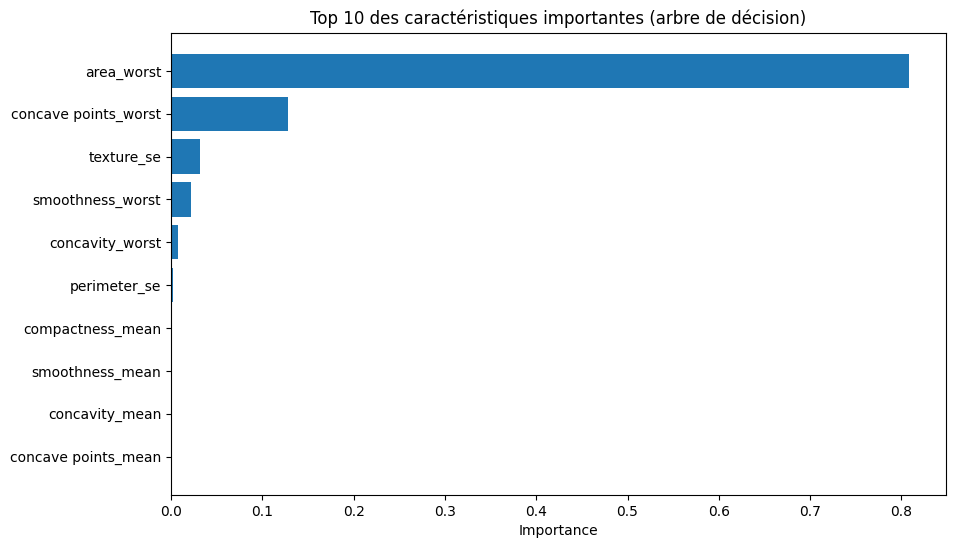

In [77]:
importances = best_dt.feature_importances_
features = x.columns

# DataFrame des importances
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

print("Top 10 des caractéristiques importantes (arbre de décision) :")
print(imp_df.head(10))

# Visualiser les importances
plt.figure(figsize=(10,6))
plt.barh(imp_df['Feature'][:10][::-1], imp_df['Importance'][:10][::-1])
plt.xlabel("Importance")
plt.title("Top 10 des caractéristiques importantes (arbre de décision)")
plt.show()

## k-nearest neighbors (KNN)

**KNN n'a pas directement d'importance de variables car c'est un modèle basé sur la distance et non paramétrique.**

## Analyse globale
- Comparer les résultats : Les variables les plus importantes dans l’arbre de décision devraient souvent correspondre aux variables avec des coefficients importants en régression logistique.

- Interprétation clinique : Par exemple, dans ce dataset, des mesures comme la “exture_se”, “perimeter_se”, “area_worst” ou “concave points_worst” sont souvent des indicateurs importants pour différencier les tumeurs bénignes des malignes.

- Cela permet d’identifier quelles caractéristiques doivent être prioritairement étudiées ou surveillées en clinique.

# Save the models

In [78]:
import joblib

# Sauvegarder la régression logistique
joblib.dump(best_model, "models/logistic_model.pkl")

# Sauvegarder le modèle KNN
joblib.dump(best_knn, "models/knn_model.pkl")

# Sauvegarder le modèle arbre de décision
joblib.dump(best_dt, "models/decision_tree_model.pkl")

# Sauvegarder le scaler si tu as normalisé tes données
joblib.dump(scaler, "models/scaler.pkl")

['scaler.pkl']